# Social Network Ads — ML Pipeline
## EDA-1 → Preprocessing → EDA-2 → Hyperparameter Tuning → Model Saving

**Flow:** Explore raw data → discover issues → clean based on insights → confirm with EDA-2 → train models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib, os
%matplotlib inline
os.makedirs('static', exist_ok=True)

---
## Step 2: Load Dataset

In [2]:
df = pd.read_csv('social_network_ads.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (2050, 7)


,UserID,Gender,Age,EstimatedSalary,AgeGroup,SalarySlab,Purchased
0,10001,M,26.0,66870.0,Young,Medium,0
1,10002,F,28.0,57682.0,Young,Medium,0
2,10003,female,NaN,93903.0,Adult,High,1
3,10004,Female,43.0,9800.0,Adult,Low,0
4,10005,Male,49.0,64791.0,Adult,Medium,1


In [3]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())

Data Types:
UserID               int64
Gender                 str
Age                float64
EstimatedSalary    float64
AgeGroup               str
SalarySlab             str
Purchased            int64
dtype: object

Missing Values:
UserID               0
Gender               0
Age                104
EstimatedSalary    102
AgeGroup             0
SalarySlab           0
Purchased            0
dtype: int64


---
## Step 3: EDA — Part 1 (Raw Data)

Explore the **raw, uncleaned** dataset to discover issues before fixing them.
Insights from here will directly guide our preprocessing decisions.

In [4]:
print('=== Summary Statistics ===')
df.describe()

=== Summary Statistics ===


,UserID,Age,EstimatedSalary,Purchased
count,2050.000000,1946.000000,1948.000000,2050.000000
mean,11002.891220,37.599178,69414.029774,0.502439
std,577.601454,17.418091,69550.429415,0.500116
min,10001.000000,-23.000000,-45000.000000,0.000000
25%,10503.250000,29.000000,46387.250000,0.000000
50%,11006.500000,37.000000,63911.000000,1.000000
75%,11502.750000,46.000000,81485.000000,1.000000
max,12000.000000,200.000000,999995.000000,1.000000


=== Missing Value Counts ===
UserID               0
Gender               0
Age                104
EstimatedSalary    102
AgeGroup             0
SalarySlab           0
Purchased            0
dtype: int64


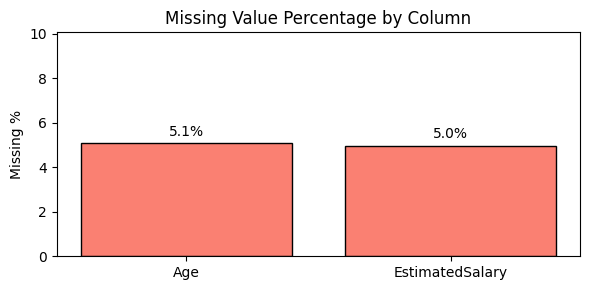

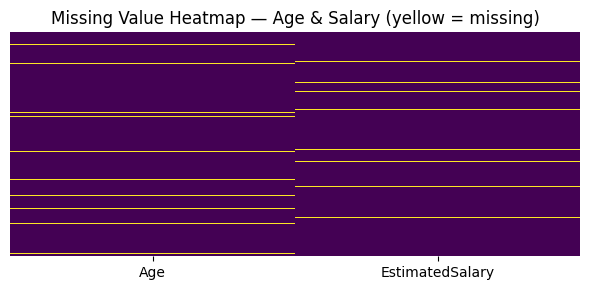

In [5]:
print('=== Missing Value Counts ===')
print(df.isnull().sum())

# Percentage bar plot — shows which columns have missing data and how much
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
plt.figure(figsize=(6, 3))
bars = plt.bar(missing_pct.index, missing_pct.values, color='salmon', edgecolor='black')
for bar, val in zip(bars, missing_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
plt.title('Missing Value Percentage by Column')
plt.ylabel('Missing %')
plt.ylim(0, missing_pct.max() + 5)
plt.tight_layout(); plt.savefig('static/eda1_missing_pct.png'); plt.show()

# Heatmap — only Age & Salary (the columns that actually have missing values)
plt.figure(figsize=(6, 3))
sns.heatmap(df[['Age', 'EstimatedSalary']].isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap — Age & Salary (yellow = missing)')
plt.tight_layout(); plt.savefig('static/eda1_missing_heatmap.png'); plt.show()

In [6]:
print('=== Gender Unique Values ===')
print(df["Gender"].value_counts())

print('\n=== AgeGroup Unique Values ===')
print(df["AgeGroup"].value_counts())

print('\n=== SalarySlab Unique Values ===')
print(df["SalarySlab"].value_counts())

=== Gender Unique Values ===
Gender
Male      538
Female    521
F         470
female    202
male      181
M         138
Name: count, dtype: int64

=== AgeGroup Unique Values ===
AgeGroup
Adult     1176
Young      539
Senior     335
Name: count, dtype: int64

=== SalarySlab Unique Values ===
SalarySlab
Medium    1352
Low        367
High       331
Name: count, dtype: int64


In [7]:
print(f'Negative Ages   : {(df["Age"] < 0).sum()}')
print(f'Negative Salaries: {(df["EstimatedSalary"] < 0).sum()}')
print(f'Duplicate rows  : {df.duplicated().sum()}')

# Show negative age rows
print('\nSample negative ages:')
print(df[df['Age'] < 0][['UserID', 'Age']].head(8))
print('\nSample negative salaries:')
print(df[df['EstimatedSalary'] < 0][['UserID', 'EstimatedSalary']].head(8))

Negative Ages   : 31
Negative Salaries: 38
Duplicate rows  : 50

Sample negative ages:
     UserID   Age
10    10011  -1.0
39    10040  -5.0
340   10341 -23.0
537   10538  -5.0
655   10656 -23.0
698   10699  -1.0
776   10777  -1.0
859   10860 -12.0

Sample negative salaries:
     UserID  EstimatedSalary
44    10045           -500.0
56    10057           -500.0
90    10091          -1200.0
121   10122           -500.0
302   10303           -500.0
309   10310          -1200.0
312   10313          -1200.0
328   10329           -500.0


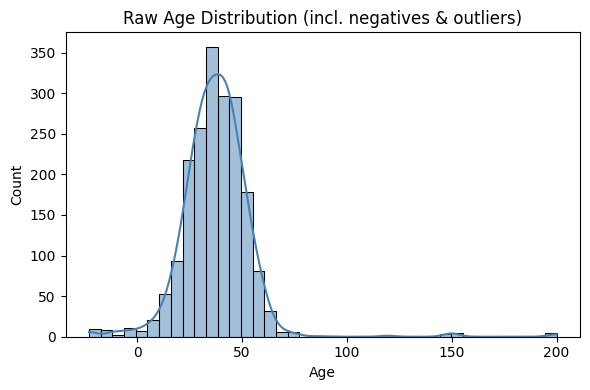

In [8]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'].dropna(), kde=True, color='steelblue', bins=40)
plt.title('Raw Age Distribution (incl. negatives & outliers)')
plt.tight_layout(); plt.savefig('static/eda1_age_dist.png'); plt.show()

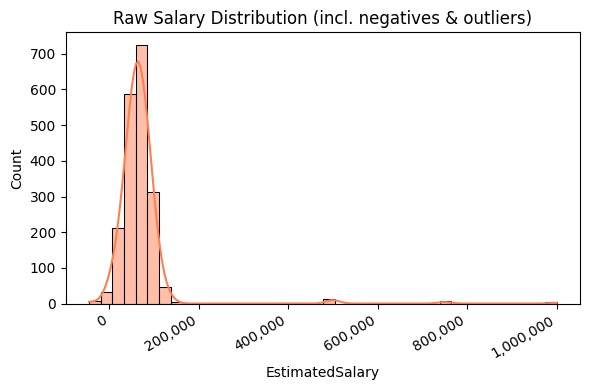

In [9]:
plt.figure(figsize=(6, 4))
sns.histplot(df['EstimatedSalary'].dropna(), kde=True, color='coral', bins=40)
plt.title('Raw Salary Distribution (incl. negatives & outliers)')
# Show actual salary values instead of scientific notation
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig('static/eda1_salary_dist.png'); plt.show()

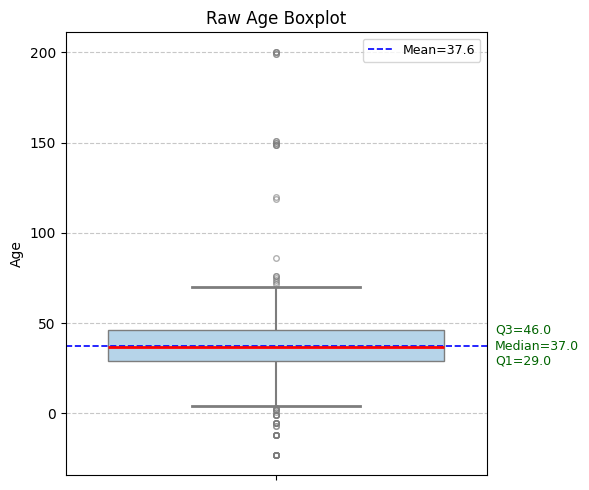

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df['Age'].dropna(), ax=ax, color='#AED6F1',
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
# Annotate Q1, median, Q3
q1, med, q3 = df['Age'].dropna().quantile([0.25, 0.5, 0.75])
mean_val = df['Age'].dropna().mean()
ax.axhline(mean_val, color='blue', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
for val, lbl in [(q1,'Q1'),(med,'Median'),(q3,'Q3')]:
    ax.text(0.52, val, f'{lbl}={val:.1f}', va='center', fontsize=9, color='darkgreen')
ax.legend(fontsize=9)
ax.set_title('Raw Age Boxplot')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda1_age_box.png'); plt.show()

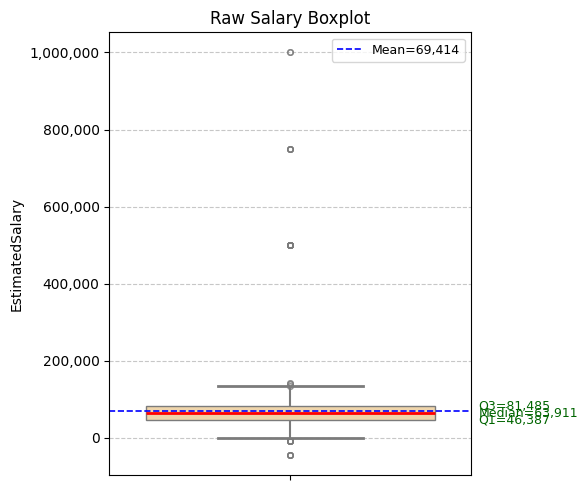

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df['EstimatedSalary'].dropna(), ax=ax, color='#FAD7A0',
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
q1, med, q3 = df['EstimatedSalary'].dropna().quantile([0.25, 0.5, 0.75])
mean_val = df['EstimatedSalary'].dropna().mean()
ax.axhline(mean_val, color='blue', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:,.0f}')
for val, lbl in [(q1,'Q1'),(med,'Median'),(q3,'Q3')]:
    ax.text(0.52, val, f'{lbl}={val:,.0f}', va='center', fontsize=9, color='darkgreen')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Raw Salary Boxplot')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda1_salary_box.png'); plt.show()

Purchased value counts:
Purchased
1    1030
0    1020
Name: count, dtype: int64


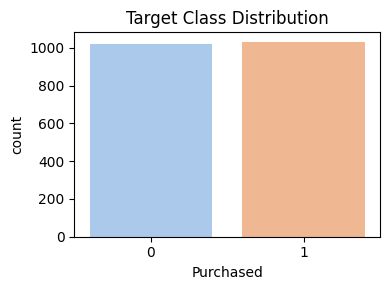

In [12]:
# Class balance check
print('Purchased value counts:')
print(df['Purchased'].value_counts())
plt.figure(figsize=(4, 3))
sns.countplot(x='Purchased', data=df, palette='pastel', hue='Purchased', legend=False)
plt.title('Target Class Distribution')
plt.tight_layout(); plt.savefig('static/eda1_target.png'); plt.show()

### EDA-1 Insights → Preprocessing Actions

| Insight Found | Action to Take |
|---|---|
| Duplicate rows present | Remove duplicates |
| Gender has 6 inconsistent variants | Standardize to Male/Female |
| Negative Age values | Replace with NaN → median impute |
| Negative Salary values | Replace with NaN → median impute |
| Missing values in Age & Salary | Median imputation |
| Extreme outliers in Age & Salary (boxplots) | IQR-based removal |
| AgeGroup & SalarySlab are derived columns | Drop — confirmed after correlation heatmap |
| UserID is an identifier | Drop — no predictive signal |
| Gender correlation with Purchased unknown yet | Encode Gender → run heatmap → decide |

---
## Step 4: Data Preprocessing & Cleaning

Each step below is directly motivated by an insight from EDA-1.

### 4a. Remove Duplicate Rows
**Why:** EDA-1 showed duplicate rows exist — they bias model training.

In [13]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)} rows. Shape now: {df.shape}')

Duplicates removed: 50 rows. Shape now: (2000, 7)


### 4b. Standardize Gender Values
**Why:** EDA-1 showed 6 inconsistent variants (Male, male, M, Female, female, F).

In [14]:
gender_map = {'Male': 'Male', 'male': 'Male', 'M': 'Male',
              'Female': 'Female', 'female': 'Female', 'F': 'Female'}
df['Gender'] = df['Gender'].map(gender_map)
print('Gender after standardization:', df['Gender'].unique())
print(df["Gender"].value_counts())

Gender after standardization: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Gender
Female    1160
Male       840
Name: count, dtype: int64


### 4c. Handle Invalid (Negative) Ages
**Why:** EDA-1 revealed negative age values — logically impossible, caused by data entry errors.
Replaced with `NaN` (not dropped) to preserve the rest of the row.

In [15]:
neg_count = (df['Age'] < 0).sum()
print(f'Negative age values found: {neg_count}')
df['Age'] = df['Age'].where(df['Age'] >= 0, other=np.nan)
print(f'Missing Age count after replacement: {df["Age"].isna().sum()}')

Negative age values found: 29
Missing Age count after replacement: 129


### 4d. Handle Invalid (Negative) Salaries
**Why:** EDA-1 revealed negative salary values — a person cannot earn a negative income.
Same approach as negative ages — replace with `NaN`.

In [16]:
neg_sal = (df['EstimatedSalary'] < 0).sum()
print(f'Negative salary values found: {neg_sal}')
df['EstimatedSalary'] = df['EstimatedSalary'].where(df['EstimatedSalary'] >= 0, other=np.nan)
print(f'Missing Salary count after replacement: {df["EstimatedSalary"].isna().sum()}')

Negative salary values found: 37
Missing Salary count after replacement: 137


### 4e. Handle Missing Values — Median Imputation
**Why:** EDA-1 showed missing values in Age & Salary. Median is used (not mean) because EDA-1 showed skewed distributions with outliers.
Also fills the NaNs created from negative age/salary replacements above.
After imputation, both `Age` and `EstimatedSalary` are cast to `int` — whole numbers only.

In [17]:
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
salary_median = df['EstimatedSalary'].median()
df['EstimatedSalary'] = df['EstimatedSalary'].fillna(salary_median)
df['Age'] = df['Age'].astype(int)
df['EstimatedSalary'] = df['EstimatedSalary'].astype(int)
print('Missing values after imputation:')
print(df.isnull().sum())
print(f'Age dtype: {df["Age"].dtype}')

Missing values after imputation:
UserID             0
Gender             0
Age                0
EstimatedSalary    0
AgeGroup           0
SalarySlab         0
Purchased          0
dtype: int64
Age dtype: int64


### 4h. Encode Gender — Male=1, Female=0
**Why:** ML models require numeric input. Encoding is needed before we can run the correlation heatmap.

In [18]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print('Gender encoded: Male=1, Female=0')
df.head()

Gender encoded: Male=1, Female=0


,UserID,Gender,Age,EstimatedSalary,AgeGroup,SalarySlab,Purchased
0,10001,1,26,66870,Young,Medium,0
1,10002,0,28,57682,Young,Medium,0
2,10003,0,38,93903,Adult,High,1
3,10004,0,43,9800,Adult,Low,0
4,10005,1,49,64791,Adult,Medium,1


### 4i. Correlation Heatmap → Feature Drop Decision

Now that Gender is numeric, we can run a full correlation heatmap.
This tells us which features actually relate to `Purchased` and which are noise.

**Expected findings:**
- `EstimatedSalary` → strong positive correlation with Purchased
- `Age` → moderate positive correlation
- `Gender` → near-zero correlation → **drop it**

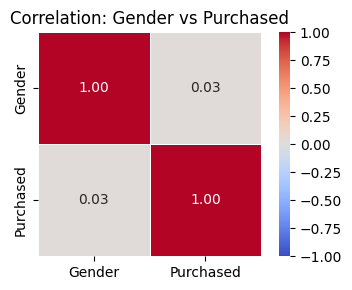

Gender-Purchased correlation: 0.0263
Insight: correlation ≈ 0 → Gender has no predictive power → will be dropped


In [19]:
# Show only Gender vs Purchased correlation — Gender is now numeric (0/1)
corr_val = df[['Gender', 'Purchased']].corr()
plt.figure(figsize=(4, 3))
sns.heatmap(corr_val, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation: Gender vs Purchased')
plt.tight_layout(); plt.savefig('static/corr_heatmap.png'); plt.show()
print(f'Gender-Purchased correlation: {df["Gender"].corr(df["Purchased"]):.4f}')
print('Insight: correlation ≈ 0 → Gender has no predictive power → will be dropped')

### 4j. Drop Useless Columns

Based on the correlation heatmap and domain knowledge, we drop 4 columns:

| Column | Reason |
|---|---|
| `Gender` | Correlation with Purchased ≈ -0.02 — near zero, adds noise not signal |
| `UserID` | Identifier only — no predictive value |
| `AgeGroup` | Derived from `Age` — redundant, causes multicollinearity |
| `SalarySlab` | Derived from `EstimatedSalary` — redundant, causes multicollinearity |

> Dropped **before** outlier treatment so IQR only runs on relevant columns.

In [20]:
df.drop(columns=['Gender', 'UserID', 'AgeGroup', 'SalarySlab'], inplace=True)
print('Remaining columns:', df.columns.tolist())

Remaining columns: ['Age', 'EstimatedSalary', 'Purchased']


### 4k. Outlier Treatment — IQR Method
**Why:** EDA-1 boxplots clearly showed extreme outliers in Age and Salary.
IQR method: remove values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [21]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    before = len(dataframe)
    dataframe = dataframe[(dataframe[column] >= Q1 - 1.5*IQR) & (dataframe[column] <= Q3 + 1.5*IQR)]
    print(f"  {column}: {before - len(dataframe)} outliers removed")
    return dataframe

df = remove_outliers_iqr(df, 'Age')
df = remove_outliers_iqr(df, 'EstimatedSalary')
print(f'Shape after outlier removal: {df.shape}')

  Age: 43 outliers removed
  EstimatedSalary: 39 outliers removed
Shape after outlier removal: (1918, 3)


### 4l. Train-Test Split & Feature Scaling
**Why scaling:** Age (~18-65) and Salary (~20k-150k) are on very different scales.
StandardScaler normalizes them so no feature dominates distance-based models (KNN).
**Important:** Scaler is fit only on training data to prevent data leakage from test set.

In [22]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('Scaled with StandardScaler.')

Train: (1534, 2)  Test: (384, 2)
Scaled with StandardScaler.


---
## Step 5: EDA — Part 2 (Clean Data)

Confirm preprocessing worked and extract meaningful insights for model building.

In [23]:
print('=== Summary Statistics (Clean Data) ===')
df.describe()

=== Summary Statistics (Clean Data) ===


,Age,EstimatedSalary,Purchased
count,1918.000000,1918.000000,1918.000000
mean,37.555787,63436.198123,0.489051
std,11.048372,23118.785077,0.500010
min,8.000000,9511.000000,0.000000
25%,30.000000,48772.750000,0.000000
50%,38.000000,64230.000000,0.000000
75%,45.000000,78486.000000,1.000000
max,67.000000,127082.000000,1.000000


Class balance after preprocessing:
Purchased
0    980
1    938
Name: count, dtype: int64

Class ratio: {0: 0.511, 1: 0.489}


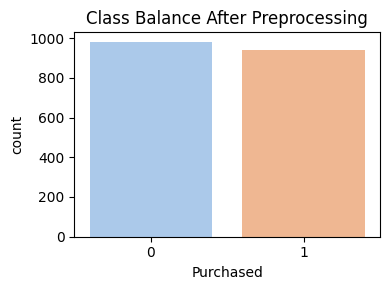

In [24]:
print('Class balance after preprocessing:')
print(df['Purchased'].value_counts())
print(f'\nClass ratio: {df["Purchased"].value_counts(normalize=True).round(3).to_dict()}')
plt.figure(figsize=(4, 3))
sns.countplot(x='Purchased', data=df, palette='pastel', hue='Purchased', legend=False)
plt.title('Class Balance After Preprocessing')
plt.tight_layout(); plt.show()

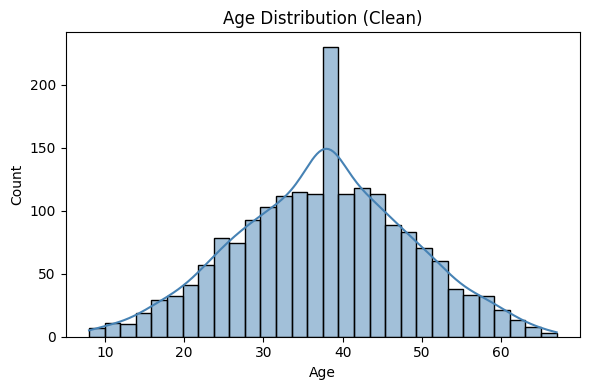

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, color='steelblue', bins=30)
plt.title('Age Distribution (Clean)')
plt.tight_layout(); plt.savefig('static/eda2_age_dist.png'); plt.show()

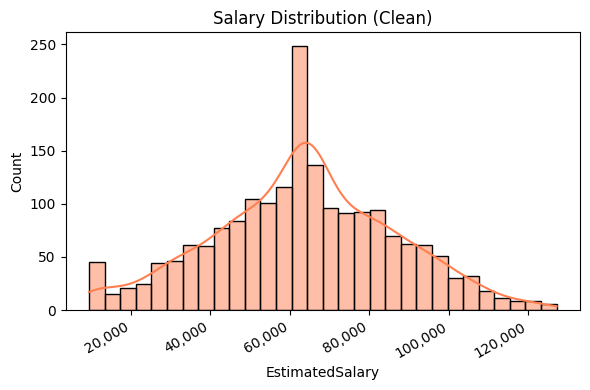

In [26]:
plt.figure(figsize=(6, 4))
sns.histplot(df['EstimatedSalary'], kde=True, color='coral', bins=30)
plt.title('Salary Distribution (Clean)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig('static/eda2_salary_dist.png'); plt.show()

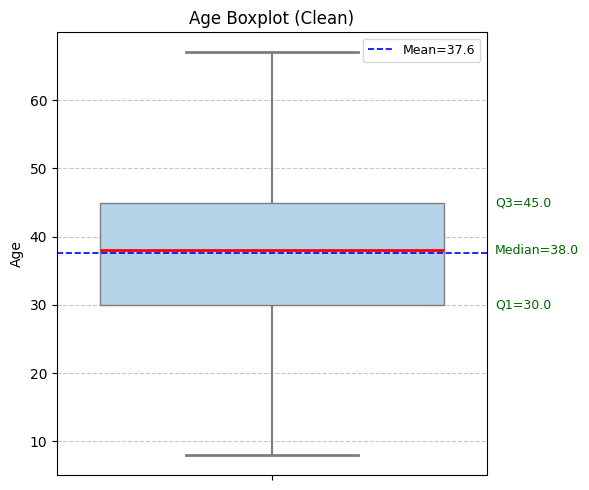

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df['Age'], ax=ax, color='#AED6F1',
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
q1, med, q3 = df['Age'].quantile([0.25, 0.5, 0.75])
mean_val = df['Age'].mean()
ax.axhline(mean_val, color='blue', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:.1f}')
for val, lbl in [(q1,'Q1'),(med,'Median'),(q3,'Q3')]:
    ax.text(0.52, val, f'{lbl}={val:.1f}', va='center', fontsize=9, color='darkgreen')
ax.legend(fontsize=9)
ax.set_title('Age Boxplot (Clean)')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda2_age_box.png'); plt.show()

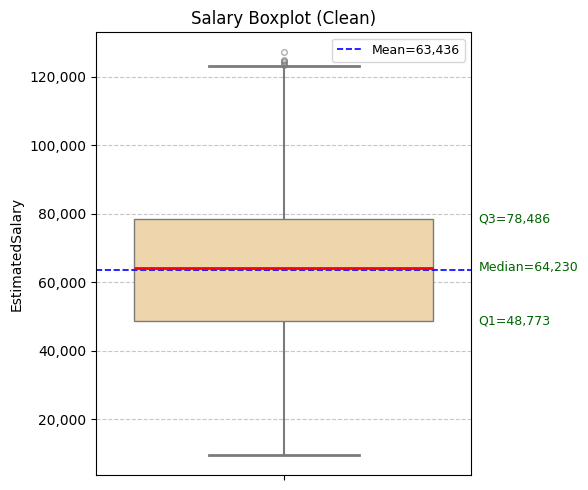

In [28]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(y=df['EstimatedSalary'], ax=ax, color='#FAD7A0',
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
q1, med, q3 = df['EstimatedSalary'].quantile([0.25, 0.5, 0.75])
mean_val = df['EstimatedSalary'].mean()
ax.axhline(mean_val, color='blue', linestyle='--', linewidth=1.2, label=f'Mean={mean_val:,.0f}')
for val, lbl in [(q1,'Q1'),(med,'Median'),(q3,'Q3')]:
    ax.text(0.52, val, f'{lbl}={val:,.0f}', va='center', fontsize=9, color='darkgreen')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Salary Boxplot (Clean)')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda2_salary_box.png'); plt.show()

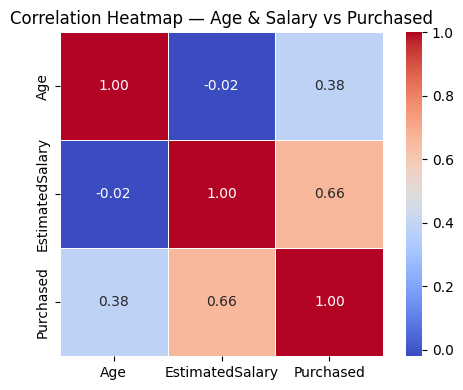

Final feature columns: ['Age', 'EstimatedSalary', 'Purchased']


In [29]:
# Correlation heatmap — Age & Salary vs Purchased on clean data
corr_data = df[['Age', 'EstimatedSalary', 'Purchased']].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap — Age & Salary vs Purchased')
plt.tight_layout(); plt.savefig('static/eda2_corr_heatmap.png'); plt.show()
print('Final feature columns:', df.columns.tolist())

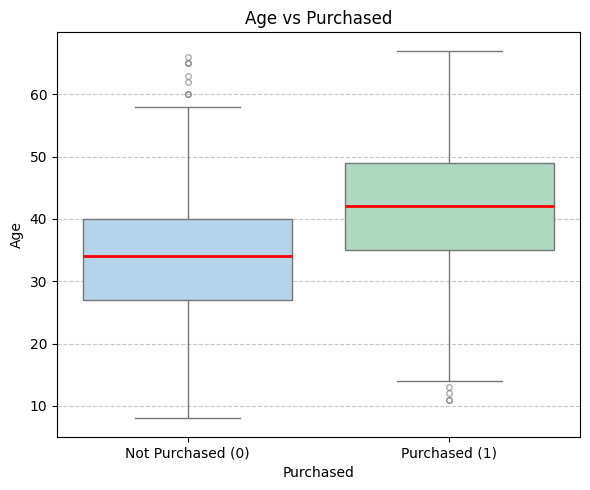

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='Purchased', y='Age', data=df, ax=ax,
            hue='Purchased', palette={0:'#AED6F1', 1:'#A9DFBF'}, legend=False,
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Purchased (0)', 'Purchased (1)'])
ax.set_title('Age vs Purchased')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda2_age_vs_target.png'); plt.show()

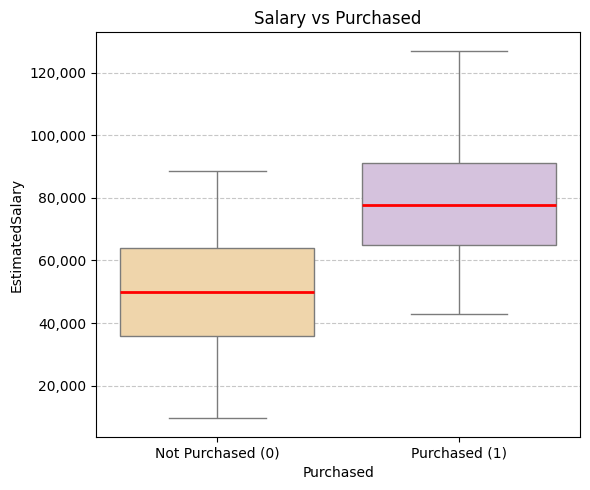

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(x='Purchased', y='EstimatedSalary', data=df, ax=ax,
            hue='Purchased', palette={0:'#FAD7A0', 1:'#D7BDE2'}, legend=False,
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', color='tomato', markersize=4, alpha=0.6))
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Purchased (0)', 'Purchased (1)'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Salary vs Purchased')
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.savefig('static/eda2_salary_vs_target.png'); plt.show()

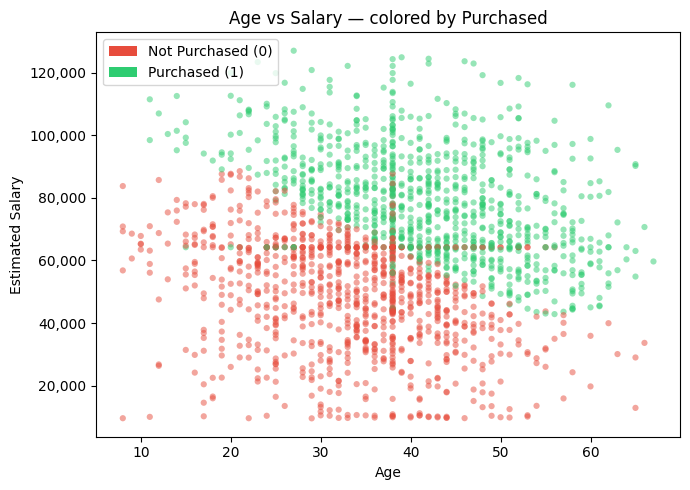

Insight: high salary + older age → purchased (green cluster top-right)


In [32]:
# Most powerful EDA chart — shows the decision boundary visually
plt.figure(figsize=(7, 5))
colors = df['Purchased'].map({0: '#E74C3C', 1: '#2ECC71'})
plt.scatter(df['Age'], df['EstimatedSalary'], c=colors, alpha=0.5, edgecolors='none', s=20)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', label='Not Purchased (0)'),
                   Patch(facecolor='#2ECC71', label='Purchased (1)')]
plt.legend(handles=legend_elements)
plt.xlabel('Age'); plt.ylabel('Estimated Salary')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.title('Age vs Salary — colored by Purchased')
plt.tight_layout(); plt.savefig('static/eda2_scatter.png'); plt.show()
print('Insight: high salary + older age → purchased (green cluster top-right)')

### EDA-2 Insights → Model Building Decisions

| Insight | Impact on Model |
|---|---|
| Higher salary → more likely to purchase | Salary is the strongest feature |
| Older age → slightly more likely to purchase | Age is a useful feature |
| Gender was dropped (correlation ≈ -0.02) | Only Age & Salary used as features |
| Age & Salary on different scales | Confirms StandardScaler was necessary |
| Classes are roughly balanced | No need for class weighting or resampling |

---
## Step 6: Model Building, Hyperparameter Tuning & Evaluation

GridSearchCV with 5-fold cross-validation.
**Why these models:**
- Logistic Regression — interpretable baseline; works well when boundary is roughly linear
- KNN — non-parametric; captures non-linear patterns; sensitive to scale (hence StandardScaler)
- SVM — finds the optimal hyperplane with maximum margin; works well in high-dimensional space; kernel trick handles non-linearity

In [33]:
from sklearn.metrics import roc_auc_score

def tune_and_evaluate(name, estimator, param_grid, X_tr, y_tr, X_te, y_te):
    grid = GridSearchCV(estimator, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_tr, y_tr)
    best = grid.best_estimator_
    y_pred = best.predict(X_te)
    y_prob = best.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    print(f"\n{chr(61)*55}\n  {name}\n{chr(61)*55}")
    print(f"Best Params  : {grid.best_params_}")
    print(f"CV Accuracy  : {grid.best_score_:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"ROC-AUC Score: {auc:.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_te, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred))
    return best, acc, auc

### Model 1: Logistic Regression
**Tuned:** `C` (regularization strength), `penalty` (l1/l2), `solver` (liblinear)

In [34]:
lr_model, lr_acc, lr_auc = tune_and_evaluate(
    'Logistic Regression',
    LogisticRegression(random_state=42, max_iter=1000),
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
    X_train_scaled, y_train, X_test_scaled, y_test
)


  Logistic Regression
Best Params  : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
CV Accuracy  : 0.9355
Test Accuracy: 0.9375
ROC-AUC Score: 0.9792

Confusion Matrix:
[[181  15]
 [  9 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       196
           1       0.92      0.95      0.94       188

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.94      0.94      0.94       384



c:\Users\shubh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Model 2: K-Nearest Neighbors
**Tuned:** `n_neighbors` (k), `weights` (uniform/distance), `metric` (euclidean/manhattan)

In [35]:
knn_model, knn_acc, knn_auc = tune_and_evaluate(
    'K-Nearest Neighbors',
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9, 11, 15], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']},
    X_train_scaled, y_train, X_test_scaled, y_test
)


  K-Nearest Neighbors
Best Params  : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
CV Accuracy  : 0.9355
Test Accuracy: 0.9427
ROC-AUC Score: 0.9864

Confusion Matrix:
[[186  10]
 [ 12 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       196
           1       0.95      0.94      0.94       188

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.94      0.94      0.94       384



### Model 3: Support Vector Machine (SVM)
**Tuned:** `C` (regularization), `kernel` (rbf/linear/poly), `gamma` (kernel coefficient)
- `C` controls trade-off between smooth boundary and classifying training points correctly
- `rbf` kernel maps data to higher dimensions to find non-linear boundaries
- Requires scaled features — already done with StandardScaler

In [36]:
svm_model, svm_acc, svm_auc = tune_and_evaluate(
    'Support Vector Machine',
    SVC(random_state=42, probability=True),
    {'C': [0.1, 1, 10, 100], 'kernel': ['rbf', 'linear', 'poly'], 'gamma': ['scale', 'auto']},
    X_train_scaled, y_train, X_test_scaled, y_test
)


  Support Vector Machine
Best Params  : {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
CV Accuracy  : 0.9387
Test Accuracy: 0.9401
ROC-AUC Score: 0.9784

Confusion Matrix:
[[182  14]
 [  9 179]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       196
           1       0.93      0.95      0.94       188

    accuracy                           0.94       384
   macro avg       0.94      0.94      0.94       384
weighted avg       0.94      0.94      0.94       384



### Model Evaluation & Comparison

              Model  Accuracy  ROC-AUC
                KNN  0.942708 0.986444
                SVM  0.940104 0.978357
Logistic Regression  0.937500 0.979225


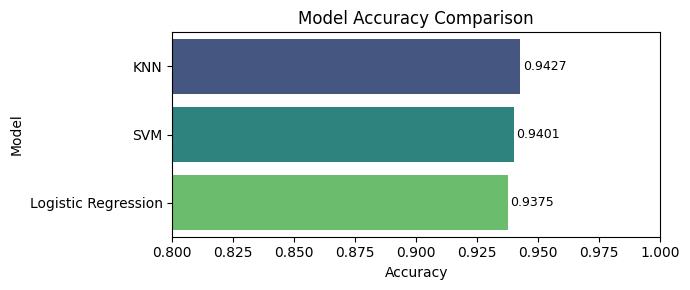

In [37]:
# Cell 1 — Accuracy Comparison
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM'],
    'Accuracy': [lr_acc, knn_acc, svm_acc],
    'ROC-AUC': [lr_auc, knn_auc, svm_auc]
})
results = results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))
plt.figure(figsize=(7, 3))
sns.barplot(x='Accuracy', y='Model', data=results, hue='Model', palette='viridis', legend=False)
plt.xlim(0.8, 1.0)
for i, v in enumerate(results['Accuracy']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.title('Model Accuracy Comparison')
plt.tight_layout(); plt.show()

              Model   Class  Precision   Recall  F1-Score  Support
Logistic Regression Class 0   0.952632 0.923469  0.937824    196.0
Logistic Regression Class 1   0.922680 0.952128  0.937173    188.0
                KNN Class 0   0.939394 0.948980  0.944162    196.0
                KNN Class 1   0.946237 0.936170  0.941176    188.0
                SVM Class 0   0.952880 0.928571  0.940568    196.0
                SVM Class 1   0.927461 0.952128  0.939633    188.0


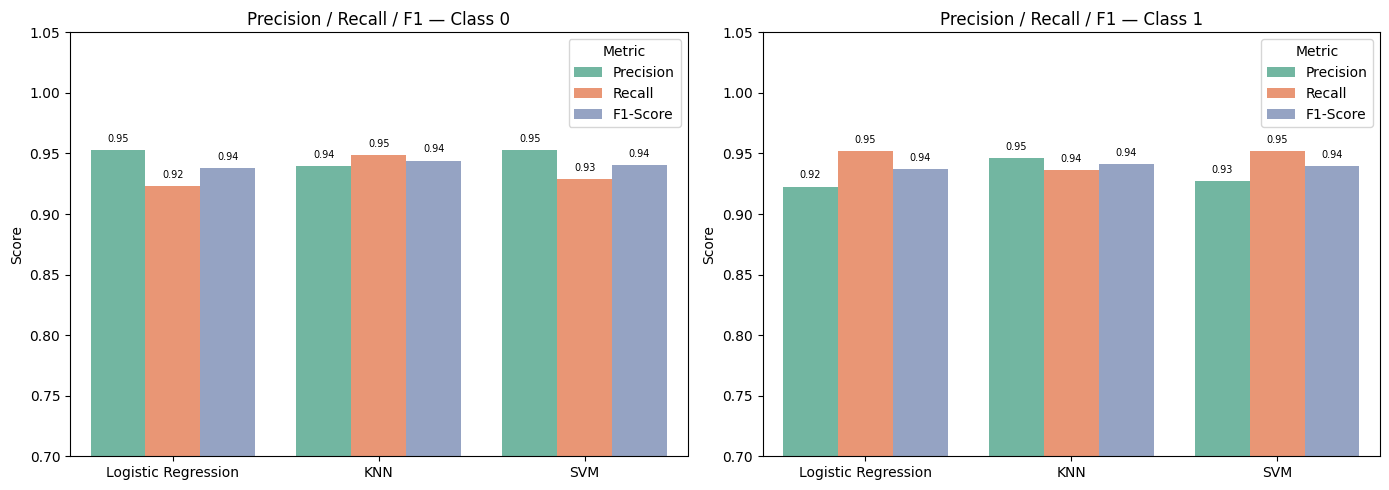

In [38]:
# Cell 2 — Precision, Recall, F1-Score & Support (Grouped Bar Chart)
from sklearn.metrics import classification_report
import warnings; warnings.filterwarnings("ignore")

models = {
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'SVM': svm_model
}

metrics_rows = []
for name, m in models.items():
    report = classification_report(y_test, m.predict(X_test_scaled), output_dict=True)
    for cls in ['0', '1']:
        metrics_rows.append({
            'Model': name,
            'Class': f'Class {cls}',
            'Precision': report[cls]['precision'],
            'Recall': report[cls]['recall'],
            'F1-Score': report[cls]['f1-score'],
            'Support': report[cls]['support']
        })
metrics_df = pd.DataFrame(metrics_rows)
print(metrics_df.to_string(index=False))

# Grouped bar chart for Precision, Recall, F1
plot_df = metrics_df.melt(id_vars=['Model', 'Class'],
                           value_vars=['Precision', 'Recall', 'F1-Score'],
                           var_name='Metric', value_name='Score')
plot_df['Model_Class'] = plot_df['Model'] + '\n' + plot_df['Class']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, cls in enumerate(['Class 0', 'Class 1']):
    sub = plot_df[plot_df['Class'] == cls]
    sns.barplot(x='Model', y='Score', hue='Metric', data=sub, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Precision / Recall / F1 — {cls}')
    axes[i].set_ylim(0.7, 1.05)
    axes[i].set_xlabel('')
    for bar in axes[i].patches:
        h = bar.get_height()
        if h > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.005,
                         f'{h:.2f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()

              Model  ROC-AUC
                KNN 0.986444
Logistic Regression 0.979225
                SVM 0.978357


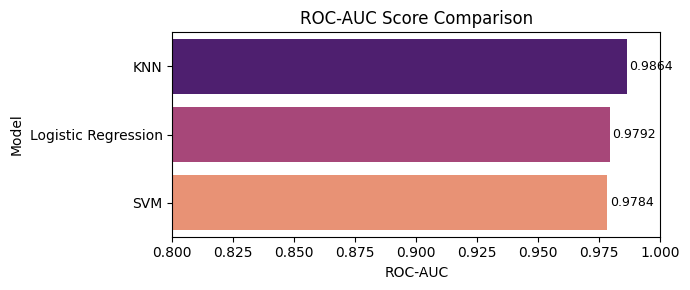

In [39]:
# Cell 3 — ROC-AUC Comparison
auc_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM'],
    'ROC-AUC': [lr_auc, knn_auc, svm_auc]
})
auc_df = auc_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False))
plt.figure(figsize=(7, 3))
bars = sns.barplot(x='ROC-AUC', y='Model', data=auc_df, hue='Model', palette='magma', legend=False)
plt.xlim(0.8, 1.0)
for i, v in enumerate(auc_df['ROC-AUC']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.title('ROC-AUC Score Comparison')
plt.tight_layout(); plt.show()

---
## Step 7: Save Best Model & Scaler

In [40]:
best_model = max(
    [(lr_model, lr_auc, "Logistic Regression"),
     (knn_model, knn_auc, "KNN"),
     (svm_model, svm_auc, "SVM")],
    key=lambda x: x[1]
)
print(f"Best model: {best_model[2]} (ROC-AUC={best_model[1]:.4f})")
joblib.dump(best_model[0], 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Saved: model.pkl, scaler.pkl')

Best model: KNN (ROC-AUC=0.9864)
Saved: model.pkl, scaler.pkl
